# DTEN AI & Machine Learning Internship — Task 2

## Movie Review Sentiment Analysis with Negation-Aware Contrastive Centroid Classification

This project is completing **Task 2: Sentiment Analysis on Text Data** from the Daryl Tech & Educational Network AI and Machine Learning internship.

The project is classifying movie reviews into three sentiment classes:

- Negative
- Neutral
- Positive

The model is using tokenization, stopword removal, negation-aware preprocessing, TF-IDF word and phrase features, and a project-specific algorithm called **Negation-Aware Contrastive Centroid Classification**.

### Dataset links

- Primary Kaggle source: [Sentiment Analysis on Movie Reviews](https://www.kaggle.com/c/sentiment-analysis-on-movie-reviews)
- Reproducible public fallback: [SST-5 on Hugging Face](https://huggingface.co/datasets/SetFit/sst5)

The Kaggle competition provides five sentiment levels. The project is mapping them to the three classes required by the internship task: labels 0–1 are becoming negative, label 2 is remaining neutral, and labels 3–4 are becoming positive.

In [1]:
# Installing the required packages for Colab execution
!pip -q install kagglehub datasets nltk seaborn scikit-learn scipy matplotlib pandas numpy

error: No virtual environment found; run `uv venv` to create an environment, or
       pass `--system` to install into a non-virtual environment


In [2]:
# Importing the libraries that are supporting the sentiment-analysis workflow
import os
import re
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from scipy.sparse import csr_matrix

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

nltk.download("stopwords", quiet=True)
english_stopwords = set(stopwords.words("english"))

print("Libraries are importing successfully.")

Libraries are importing successfully.


## 1. Loading the movie-review dataset

The notebook is attempting to load the Kaggle competition data first. If Kaggle authentication is unavailable in the Colab session, the notebook is automatically loading the public SST-5 movie-review corpus from Hugging Face. Both sources are containing fine-grained movie-review sentiment labels.

In [3]:
# Defining the five-level-to-three-level sentiment mapping

def map_five_level_to_three_level(label):
    # Mapping the original score ranges into the assignment classes
    label = int(label)
    if label in [0, 1]:
        return "negative"
    if label == 2:
        return "neutral"
    if label in [3, 4]:
        return "positive"
    raise ValueError(f"Unexpected sentiment label: {label}")

# Defining a loader that is attempting Kaggle before using the public fallback

def load_movie_reviews():
    # Trying to download the Kaggle competition files
    try:
        import kagglehub
        downloaded_path = kagglehub.competition_download(
            "sentiment-analysis-on-movie-reviews"
        )
        train_files = glob.glob(
            os.path.join(downloaded_path, "**", "train.tsv"),
            recursive=True
        )
        if train_files:
            kaggle_df = pd.read_csv(train_files[0], sep="\t")
            kaggle_df["text"] = kaggle_df["Phrase"].astype(str)
            kaggle_df["sentiment"] = kaggle_df["Sentiment"].apply(
                map_five_level_to_three_level
            )
            kaggle_df["source"] = "Kaggle Sentiment Analysis on Movie Reviews"
            return kaggle_df[["text", "sentiment", "source"]]
    except Exception as error:
        print("Kaggle download is requiring authentication in this session.")
        print("The public SST-5 fallback is being loaded instead.")

    # Loading the public five-level SST-5 movie-review corpus
    from datasets import load_dataset
    sst5 = load_dataset("SetFit/sst5")
    frames = []
    for split_name in ["train", "validation", "test"]:
        split_df = sst5[split_name].to_pandas()
        split_df["text"] = split_df["text"].astype(str)
        split_df["sentiment"] = split_df["label"].apply(
            map_five_level_to_three_level
        )
        split_df["source"] = "SetFit SST-5 on Hugging Face"
        frames.append(split_df[["text", "sentiment", "source"]])
    return pd.concat(frames, ignore_index=True)

reviews_df = load_movie_reviews()
print("Loaded source:", reviews_df["source"].iloc[0])
print("Dataset shape:", reviews_df.shape)
display(reviews_df.head())

Kaggle download is requiring authentication in this session.
The public SST-5 fallback is being loaded instead.


Repo card metadata block was not found. Setting CardData to empty.


Loaded source: SetFit SST-5 on Hugging Face
Dataset shape: (11855, 3)


,text,sentiment,source
0,"a stirring , funny and finally transporting re...",positive,SetFit SST-5 on Hugging Face
1,apparently reassembled from the cutting-room f...,negative,SetFit SST-5 on Hugging Face
2,they presume their audience wo n't sit still f...,negative,SetFit SST-5 on Hugging Face
3,the entire movie is filled with deja vu moments .,neutral,SetFit SST-5 on Hugging Face
4,this is a visually stunning rumination on love...,positive,SetFit SST-5 on Hugging Face


Class distribution:


sentiment
positive    4958
negative    4644
neutral     2239
Name: count, dtype: int64

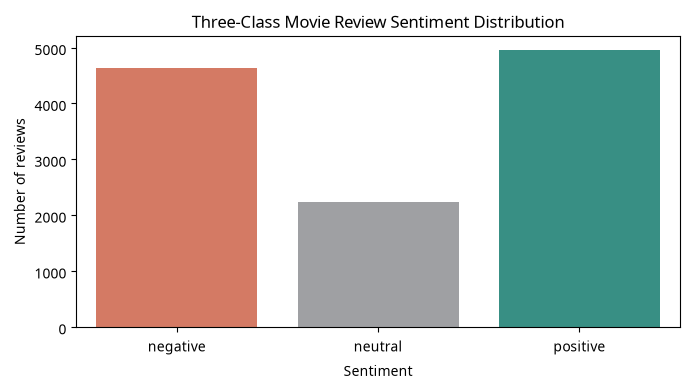

In [4]:
# Inspecting the class distribution and removing unusable records
reviews_df = reviews_df.dropna(subset=["text", "sentiment"])
reviews_df["text"] = reviews_df["text"].astype(str).str.strip()
reviews_df = reviews_df[reviews_df["text"].str.len() > 0]
reviews_df = reviews_df.drop_duplicates(subset=["text", "sentiment"])
reviews_df = reviews_df.reset_index(drop=True)

print("Class distribution:")
display(reviews_df["sentiment"].value_counts())

plt.figure(figsize=(7, 4))
sns.countplot(data=reviews_df, x="sentiment", order=["negative", "neutral", "positive"], palette=["#E76F51", "#9E9FA4", "#2A9D8F"])
plt.title("Three-Class Movie Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

## 2. Performing negation-aware text preprocessing

The preprocessing is preserving negation words such as **not**, **never**, and **no**. The next three meaningful words after a negation are receiving a `NOT_` prefix. This is helping the model distinguish expressions such as `good` and `not good` rather than treating them as equivalent.

In [5]:
# Defining the negation-aware tokenizer and stopword-removal process
NEGATION_WORDS = {
    "not", "no", "never", "neither", "nor", "cannot",
    "can't", "didn't", "doesn't", "don't", "isn't", "wasn't",
    "weren't", "won't", "wouldn't", "shouldn't", "couldn't"
}

STOPWORDS_TO_KEEP = {"not", "no", "never", "neither", "nor"}
CUSTOM_STOPWORDS = set(english_stopwords) - STOPWORDS_TO_KEEP


def negation_aware_tokenize(text):
    # Converting the review to lowercase characters
    text = str(text).lower()
    raw_tokens = re.findall(r"[a-z]+(?:'[a-z]+)?|[.!?,;:]", text)
    processed_tokens = []
    negation_active = False
    negation_count = 0

    for token in raw_tokens:
        # Resetting the negation scope at sentence punctuation
        if token in {".", "!", "?", ",", ";", ":"}:
            negation_active = False
            negation_count = 0
            continue

        clean_token = token.replace("'", "")

        # Preserving the words that are signaling negation
        if clean_token in NEGATION_WORDS:
            processed_tokens.append(clean_token)
            negation_active = True
            negation_count = 0
            continue

        # Removing ordinary stopwords while retaining sentiment-bearing terms
        if clean_token in CUSTOM_STOPWORDS:
            continue

        # Marking nearby terms when negation is remaining active
        if negation_active and negation_count < 3:
            processed_tokens.append("NOT_" + clean_token)
            negation_count += 1
            if negation_count >= 3:
                negation_active = False
        else:
            processed_tokens.append(clean_token)

    return " ".join(processed_tokens)

example_sentences = [
    "The movie was excellent and enjoyable.",
    "The movie was not excellent.",
    "I never expected such a boring film."
]

for sentence in example_sentences:
    print("Original:", sentence)
    print("Processed:", negation_aware_tokenize(sentence))
    print()

reviews_df["processed_text"] = reviews_df["text"].apply(negation_aware_tokenize)
reviews_df = reviews_df[reviews_df["processed_text"].str.len() > 0]
print("Preprocessing is completed for", len(reviews_df), "reviews.")

Original: The movie was excellent and enjoyable.
Processed: movie excellent enjoyable

Original: The movie was not excellent.
Processed: movie not NOT_excellent

Original: I never expected such a boring film.
Processed: never NOT_expected NOT_boring NOT_film

Preprocessing is completed for 11825 reviews.


## 3. Creating the train, validation, and test partitions

The data is being divided into 70% training, 15% validation, and 15% testing partitions. Stratification is preserving the approximate class proportions. The validation set is being used for selecting the neutral-confidence margin, while the test set is remaining untouched until final evaluation.

In [6]:
# Encoding the sentiment labels and creating stratified partitions
sentiment_to_number = {"negative": 0, "neutral": 1, "positive": 2}
number_to_sentiment = {value: key for key, value in sentiment_to_number.items()}

reviews_df["target"] = reviews_df["sentiment"].map(sentiment_to_number)
text_data = reviews_df["processed_text"].to_numpy()
target_data = reviews_df["target"].to_numpy()

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    text_data,
    target_data,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=target_data
)

X_validation_text, X_test_text, y_validation, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training reviews:", len(X_train_text))
print("Validation reviews:", len(X_validation_text))
print("Testing reviews:", len(X_test_text))

Training reviews: 8277
Validation reviews: 1774
Testing reviews: 1774


## 4. Converting reviews into TF-IDF features

The TF-IDF representation is including unigrams and bigrams. This is allowing the model to learn both individual sentiment words and short phrases such as `highly entertaining` and `not good`. The vectorizer is being fitted only on training text to prevent test-set leakage.

In [7]:
# Fitting the TF-IDF vectorizer on training reviews and transforming all partitions
vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=60000,
    sublinear_tf=True,
    norm="l2"
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_validation_tfidf = vectorizer.transform(X_validation_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_validation_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8277, 12154)
Validation TF-IDF shape: (1774, 12154)
Testing TF-IDF shape: (1774, 12154)


In [8]:
# Displaying high-importance vocabulary terms by average TF-IDF value
feature_names = np.array(vectorizer.get_feature_names_out())
average_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_indices = np.argsort(average_tfidf)[-25:][::-1]

top_features = pd.DataFrame({
    "feature": feature_names[top_indices],
    "average_tfidf": average_tfidf[top_indices]
})
display(top_features)

,feature,average_tfidf
0,film,0.017265
1,movie,0.016957
2,nt,0.012064
3,not,0.011762
4,like,0.010126
5,one,0.009880
6,story,0.007459
7,no,0.007098
8,rrb,0.006643
9,lrb,0.006593


## 5. Training the Negation-Aware Contrastive Centroid model

The custom algorithm is representing each sentiment class with a normalized TF-IDF centroid. It is calculating contrastive feature weights from the difference between class centroids. It is then measuring cosine similarity between each review and each centroid.

A confidence-margin rule is making the neutral class explicit: when the best and second-best class scores are too close, the review is being assigned to **neutral** rather than being forced into a confident positive or negative decision.

In [9]:
# Defining the project-specific centroid and contrastive-weighting classifier
class NegationAwareContrastiveCentroid:
    # Initializing the classifier controls for neutral uncertainty and feature contrast
    def __init__(self, neutral_margin=0.025, contrast_strength=0.50):
        self.neutral_margin = neutral_margin
        self.contrast_strength = contrast_strength

    # Fitting class centroids, feature weights, and class priors from training data
    def fit(self, X, y):
        X = csr_matrix(X)
        y = np.asarray(y)
        self.classes_ = np.sort(np.unique(y))

        centroids = []
        for class_id in self.classes_:
            class_centroid = np.asarray(X[y == class_id].mean(axis=0)).ravel()
            centroids.append(class_centroid)
        self.centroids_ = np.vstack(centroids)

        centroid_norms = np.linalg.norm(self.centroids_, axis=1, keepdims=True)
        centroid_norms[centroid_norms == 0] = 1.0
        self.normalized_centroids_ = self.centroids_ / centroid_norms

        feature_max = np.max(self.centroids_, axis=0)
        feature_min = np.min(self.centroids_, axis=0)
        contrast = feature_max - feature_min

        if contrast.max() - contrast.min() < 1e-12:
            normalized_contrast = np.ones_like(contrast)
        else:
            normalized_contrast = (contrast - contrast.min()) / (contrast.max() - contrast.min())

        self.feature_weights_ = 1.0 + self.contrast_strength * normalized_contrast
        self.class_priors_ = np.array([np.mean(y == class_id) for class_id in self.classes_])
        return self

    # Applying contrastive weighting and row normalization to review vectors
    def _weighted_normalize(self, X):
        X = csr_matrix(X)
        weighted_X = X.multiply(self.feature_weights_)
        row_norms = np.sqrt(weighted_X.multiply(weighted_X).sum(axis=1))
        row_norms = np.asarray(row_norms).ravel()
        row_norms[row_norms == 0] = 1.0
        return weighted_X.multiply(1.0 / row_norms[:, None])

    # Calculating weighted cosine-style scores for every sentiment class
    def decision_scores(self, X):
        normalized_X = self._weighted_normalize(X)
        weighted_centroids = self.normalized_centroids_ * self.feature_weights_[None, :]
        centroid_norms = np.linalg.norm(weighted_centroids, axis=1, keepdims=True)
        centroid_norms[centroid_norms == 0] = 1.0
        weighted_centroids = weighted_centroids / centroid_norms
        return np.asarray(normalized_X @ weighted_centroids.T)

    # Converting class scores into probability-like values
    def predict_proba(self, X):
        scores = self.decision_scores(X) * 8.0
        scores = scores - np.max(scores, axis=1, keepdims=True)
        exponentials = np.exp(scores)
        return exponentials / exponentials.sum(axis=1, keepdims=True)

    # Predicting classes while assigning low-margin cases to neutral
    def predict_with_margin(self, X):
        scores = self.decision_scores(X)
        sorted_scores = np.sort(scores, axis=1)
        margins = sorted_scores[:, -1] - sorted_scores[:, -2]
        predictions = self.classes_[np.argmax(scores, axis=1)].copy()
        neutral_position = np.where(self.classes_ == 1)[0][0]
        predictions[margins < self.neutral_margin] = self.classes_[neutral_position]
        return predictions, margins

    # Returning the final sentiment predictions
    def predict(self, X):
        predictions, _ = self.predict_with_margin(X)
        return predictions

custom_model = NegationAwareContrastiveCentroid(
    neutral_margin=0.025,
    contrast_strength=0.50
)
custom_model.fit(X_train_tfidf, y_train)
print("Custom model is trained successfully.")

Custom model is trained successfully.


Selected neutral margin: 0.005
Validation accuracy: 0.4983
Validation macro-F1: 0.4837


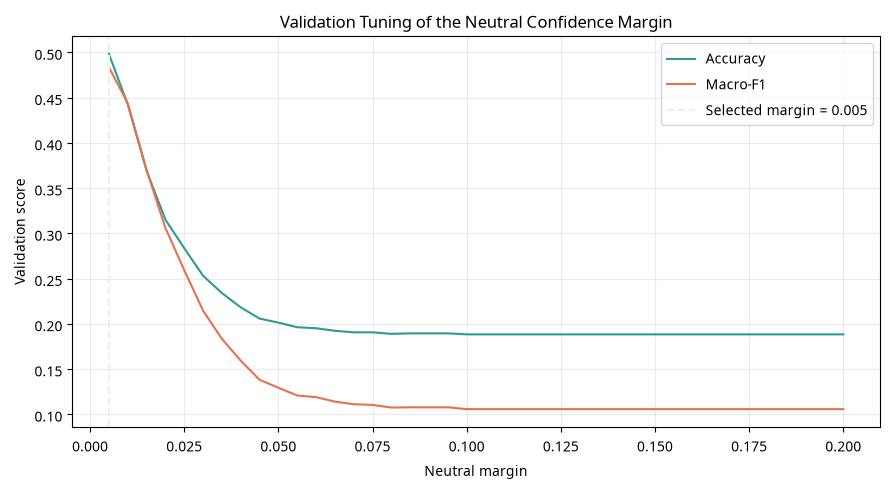

In [10]:
# Tuning the neutral-confidence margin on validation data
candidate_margins = np.linspace(0.005, 0.20, 40)
validation_results = []

for candidate_margin in candidate_margins:
    custom_model.neutral_margin = candidate_margin
    validation_predictions = custom_model.predict(X_validation_tfidf)
    validation_results.append({
        "neutral_margin": candidate_margin,
        "accuracy": accuracy_score(y_validation, validation_predictions),
        "macro_f1": f1_score(y_validation, validation_predictions, average="macro", zero_division=0)
    })

validation_results_df = pd.DataFrame(validation_results)
best_row = validation_results_df.sort_values("macro_f1", ascending=False).iloc[0]
best_margin = float(best_row["neutral_margin"])
custom_model.neutral_margin = best_margin

print("Selected neutral margin:", round(best_margin, 4))
print("Validation accuracy:", round(float(best_row["accuracy"]), 4))
print("Validation macro-F1:", round(float(best_row["macro_f1"]), 4))

plt.figure(figsize=(9, 5))
plt.plot(validation_results_df["neutral_margin"], validation_results_df["accuracy"], label="Accuracy", color="#2A9D8F")
plt.plot(validation_results_df["neutral_margin"], validation_results_df["macro_f1"], label="Macro-F1", color="#E76F51")
plt.axvline(best_margin, linestyle="--", color="#F0EFEA", label=f"Selected margin = {best_margin:.3f}")
plt.title("Validation Tuning of the Neutral Confidence Margin")
plt.xlabel("Neutral margin")
plt.ylabel("Validation score")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Evaluating the final model

The final evaluation is reporting accuracy, macro-precision, macro-recall, macro-F1, a classification report, and a confusion matrix. The displayed numbers are being generated from the held-out test partition.

In [11]:
# Generating final predictions for the untouched test partition
y_test_pred = custom_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_test_pred)
macro_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

metrics_table = pd.DataFrame({
    "metric": ["accuracy", "macro_precision", "macro_recall", "macro_f1", "selected_neutral_margin"],
    "value": [accuracy, macro_precision, macro_recall, macro_f1, best_margin]
})

display(metrics_table.round(4))

,metric,value
0,accuracy,0.5152
1,macro_precision,0.5481
2,macro_recall,0.5142
3,macro_f1,0.5030
4,selected_neutral_margin,0.0050


In [12]:
# Printing the per-class precision, recall, F1-score, and support values
class_names = ["negative", "neutral", "positive"]
print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.68      0.44      0.54       697
     neutral       0.24      0.52      0.33       334
    positive       0.72      0.58      0.65       743

    accuracy                           0.52      1774
   macro avg       0.55      0.51      0.50      1774
weighted avg       0.62      0.52      0.54      1774



,negative,neutral,positive
negative,308,309,80
neutral,76,173,85
positive,68,242,433


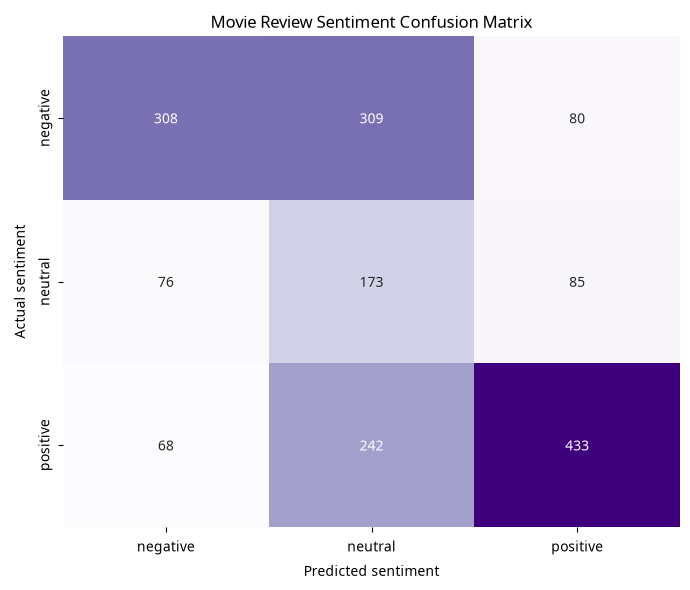

In [13]:
# Drawing and displaying the final confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
confusion_table = pd.DataFrame(cm, index=class_names, columns=class_names)
display(confusion_table)

plt.figure(figsize=(7, 6))
sns.heatmap(confusion_table, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Movie Review Sentiment Confusion Matrix")
plt.xlabel("Predicted sentiment")
plt.ylabel("Actual sentiment")
plt.tight_layout()
plt.show()

In [14]:
# Reviewing the least-confident test predictions for interpretability
_, test_margins = custom_model.predict_with_margin(X_test_tfidf)
uncertain_indices = np.argsort(test_margins)[:15]

uncertain_table = pd.DataFrame({
    "review": X_test_text[uncertain_indices],
    "actual": [number_to_sentiment[y_test[i]] for i in uncertain_indices],
    "predicted": [number_to_sentiment[y_test_pred[i]] for i in uncertain_indices],
    "confidence_margin": test_margins[uncertain_indices]
})
display(uncertain_table)

,review,actual,predicted,confidence_margin
0,degenerates hogwash,negative,neutral,0.000000
1,sa da tay,neutral,neutral,0.000000
2,magnifique,neutral,neutral,0.000000
3,scared,neutral,neutral,0.000000
4,bearable,neutral,neutral,0.000000
5,drives kind bittersweet conciliatory tone thre...,neutral,neutral,0.000015
6,calculated swill,neutral,neutral,0.000020
7,overstylized pur ed lange sex psychology drugs...,negative,neutral,0.000021
8,new jangle noise mayhem stupidity must serious...,negative,neutral,0.000031
9,value time money find escape clause avoid seei...,negative,neutral,0.000042


## 7. Limitations and conclusion

The model is remaining interpretable, but TF-IDF is not fully understanding sarcasm, irony, long-range context, or genre-specific meaning. Grouping five original labels into three classes is also reducing some sentiment detail. A future version could compare this approach with a transformer model such as BERT, add calibration, and evaluate across multiple random seeds.

The project is completing the Task 2 requirements: selecting a movie-review dataset, preprocessing text, tokenizing reviews, removing stopwords, applying TF-IDF, training a three-class sentiment model, reporting evaluation metrics, and discussing limitations.

In [15]:
# Saving the evaluation artifacts for reproducibility and GitHub review
metrics_table.to_csv("movie_sentiment_metrics.csv", index=False)
confusion_table.to_csv("movie_sentiment_confusion_matrix.csv")
uncertain_table.to_csv("movie_sentiment_uncertain_examples.csv", index=False)

print("Saving the following artifacts:")
print("- movie_sentiment_metrics.csv")
print("- movie_sentiment_confusion_matrix.csv")
print("- movie_sentiment_uncertain_examples.csv")

Saving the following artifacts:
- movie_sentiment_metrics.csv
- movie_sentiment_confusion_matrix.csv
- movie_sentiment_uncertain_examples.csv
